As our  dataset is highly imbalanced:
Non-Fraud (0): 988,971 (98.9%)
Fraud (1): 11,029 (1.1%)
Most ML algorithms will learn to predict only the majority class. In this notebook, we'll balance the dataset using SMOTE (Synthetic Minority Over-sampling Technique).

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/financial_fraud_encoded.csv")
print(df.shape)

(1000000, 48)


In [3]:
#Separate Features and Target
X = df.drop("fraud_bool", axis=1)
y = df["fraud_bool"]
print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1000000, 47)
Target Shape : (1000000,)


In [4]:
#Check Class Distribution
print(y.value_counts())
print()
print(y.value_counts(normalize=True) * 100)

fraud_bool
0    988971
1     11029
Name: count, dtype: int64

fraud_bool
0    98.8971
1     1.1029
Name: proportion, dtype: float64


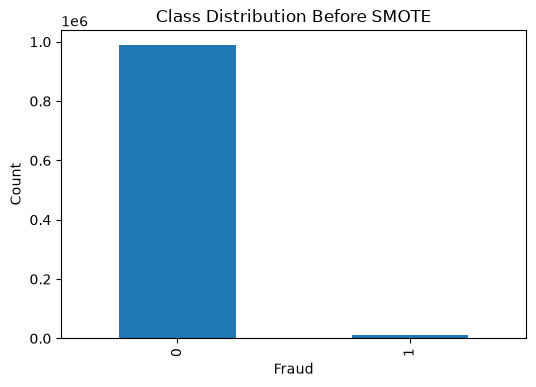

In [9]:
plt.figure(figsize=(6,4))
y.value_counts().plot(kind="bar")
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Fraud")
plt.ylabel("Count")
plt.show()

In [10]:
#split before applying SMOTE to prevent data leakage.
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)

(800000, 47)
(200000, 47)


In [11]:
#Check Training Distribution
print(Counter(y_train))

Counter({0: 791177, 1: 8823})


In [12]:
#Appling  SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

In [13]:
print(Counter(y_train_smote)) #Check Balanced Dataset

Counter({0: 791177, 1: 791177})


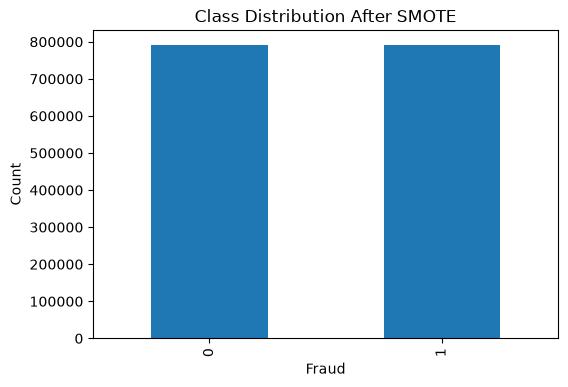

In [14]:
plt.figure(figsize=(6,4)) #visualize After SMOTE
pd.Series(y_train_smote).value_counts().plot(kind="bar")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Fraud")
plt.ylabel("Count")
plt.show()

In [15]:
#Compare Before and After
comparison = pd.DataFrame({"Before SMOTE": y_train.value_counts(),
    "After SMOTE": pd.Series(y_train_smote).value_counts()
})
comparison

,Before SMOTE,After SMOTE
fraud_bool,,
0,791177,791177
1,8823,791177


In [18]:
#Saving Balanced Training Data
train_smote = pd.concat(
    [
        pd.DataFrame(X_train_smote, columns=X.columns),
        pd.Series(y_train_smote, name="fraud_bool")
    ],
    axis=1
)
train_smote.to_csv("../data/processed/train_smote.csv",index=False)
print("Balanced training dataset saved successfully.")

Balanced training dataset saved successfully.


In [19]:
#Saving  Test Dataset
test_df = pd.concat(
    [
        X_test.reset_index(drop=True),
        y_test.reset_index(drop=True)
    ],
    axis=1
)
test_df.to_csv("../data/processed/test_data.csv",index=False)
print("Testing dataset saved successfully.")

Testing dataset saved successfully.


# Summary

- Loaded the encoded dataset.
- Split the data into training and testing sets using stratified sampling.
- Verified the severe class imbalance in the target variable.
- Applied SMOTE to the training data only.
- Generated synthetic fraud samples to balance the classes.
- Compared class distributions before and after SMOTE.
- Saved the balanced training dataset (`train_smote.csv`).
- Saved the untouched testing dataset (`test_data.csv`).

### Note

SMOTE was applied **only to the training data** to prevent data leakage and ensure a fair evaluation of machine learning models on unseen data.